In [17]:
!pip -q install torch torchvision opencv-python pandas scikit-learn matplotlib pillow

In [18]:


from google.colab import files
uploaded = files.upload()

ZIP_PATH = next(iter(uploaded))
print("Using:", ZIP_PATH)


Saving archive (1).zip to archive (1) (2).zip
Using: archive (1) (2).zip


In [19]:
import os, zipfile, shutil, glob, random, math
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

EXTRACT_DIR = "/content/gesture_dataset"

if os.path.exists(EXTRACT_DIR):
    shutil.rmtree(EXTRACT_DIR)

os.makedirs(EXTRACT_DIR, exist_ok=True)

with zipfile.ZipFile(ZIP_PATH, "r") as z:
    z.extractall(EXTRACT_DIR)

print("Extracted to:", EXTRACT_DIR)
print("Folders:", os.listdir(EXTRACT_DIR))


Extracted to: /content/gesture_dataset
Folders: ['test', 'train', 'valid']


In [20]:


for split in ["train", "valid", "test"]:
    folder = os.path.join(EXTRACT_DIR, split)
    if os.path.exists(folder):
        csvs = glob.glob(os.path.join(folder, "*_annotations.csv"))
        print(split, "CSV:", csvs)
        print("Images:", len(glob.glob(os.path.join(folder, "*.jpg"))))


train CSV: ['/content/gesture_dataset/train/_annotations.csv']
Images: 642
valid CSV: ['/content/gesture_dataset/valid/_annotations.csv']
Images: 178
test CSV: ['/content/gesture_dataset/test/_annotations.csv']
Images: 94


In [21]:


CROP_ROOT = "/content/gesture_crops"

if os.path.exists(CROP_ROOT):
    shutil.rmtree(CROP_ROOT)

os.makedirs(CROP_ROOT, exist_ok=True)

def make_crops(split):
    split_dir = os.path.join(EXTRACT_DIR, split)
    csv_files = glob.glob(os.path.join(split_dir, "*_annotations.csv"))

    if not csv_files:
        print("No annotation CSV found for", split)
        return 0

    df = pd.read_csv(csv_files[0])
    count = 0

    for i, row in df.iterrows():
        image_path = os.path.join(split_dir, str(row["filename"]))

        if not os.path.exists(image_path):
            continue

        try:
            img = Image.open(image_path).convert("RGB")
            w, h = img.size

            xmin = max(0, int(row["xmin"]))
            ymin = max(0, int(row["ymin"]))
            xmax = min(w, int(row["xmax"]))
            ymax = min(h, int(row["ymax"]))

            if xmax <= xmin or ymax <= ymin:
                continue

            crop = img.crop((xmin, ymin, xmax, ymax))


            cls = str(int(row["class"]))
            out_dir = os.path.join(CROP_ROOT, split, cls)
            os.makedirs(out_dir, exist_ok=True)

            out_path = os.path.join(out_dir, f"{count:06d}.jpg")
            crop.save(out_path, quality=95)
            count += 1

        except Exception as e:
            print("Skipped:", image_path, e)

    return count

for split in ["train", "valid", "test"]:
    if os.path.exists(os.path.join(EXTRACT_DIR, split)):
        n = make_crops(split)
        print(split, "cropped images:", n)

print("Crop dataset created at:", CROP_ROOT)


train cropped images: 641
valid cropped images: 178
test cropped images: 93
Crop dataset created at: /content/gesture_crops


In [22]:


for split in ["train", "valid", "test"]:
    root = os.path.join(CROP_ROOT, split)
    if os.path.exists(root):
        print("\n", split)
        for cls in sorted(os.listdir(root), key=lambda x: int(x)):
            n = len(glob.glob(os.path.join(root, cls, "*.jpg")))
            print("Class", cls, ":", n)



 train
Class 0 : 25
Class 1 : 52
Class 2 : 35
Class 3 : 42
Class 4 : 33
Class 5 : 47
Class 6 : 90
Class 7 : 28
Class 8 : 34
Class 9 : 66
Class 10 : 32
Class 11 : 30
Class 12 : 32
Class 13 : 95

 valid
Class 0 : 4
Class 1 : 13
Class 2 : 11
Class 3 : 10
Class 4 : 10
Class 5 : 12
Class 6 : 17
Class 7 : 7
Class 8 : 14
Class 9 : 16
Class 10 : 8
Class 11 : 14
Class 12 : 9
Class 13 : 33

 test
Class 0 : 5
Class 1 : 5
Class 2 : 1
Class 3 : 12
Class 4 : 4
Class 5 : 7
Class 6 : 11
Class 8 : 6
Class 9 : 10
Class 10 : 3
Class 11 : 10
Class 12 : 4
Class 13 : 15


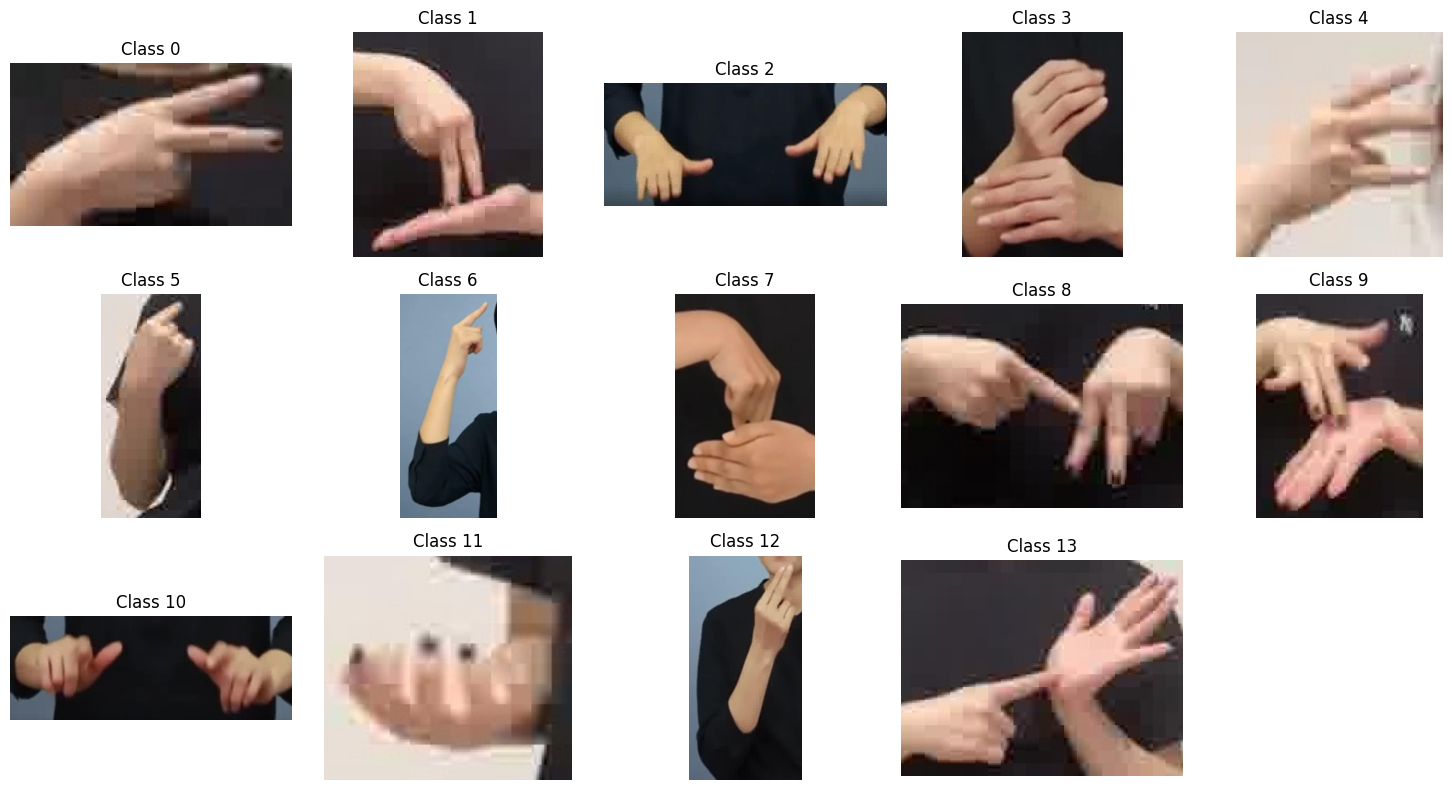

In [23]:
# Display a few cropped examples.

all_examples = []
for cls in sorted(os.listdir(os.path.join(CROP_ROOT, "train")), key=lambda x: int(x)):
    imgs = glob.glob(os.path.join(CROP_ROOT, "train", cls, "*.jpg"))
    if imgs:
        all_examples.append((cls, imgs[0]))

plt.figure(figsize=(15, 8))
for i, (cls, p) in enumerate(all_examples[:14]):
    img = Image.open(p)
    ax = plt.subplot(3, 5, i + 1)
    ax.imshow(img)
    ax.set_title("Class " + cls)
    ax.axis("off")
plt.tight_layout()
plt.show()


In [24]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10
LEARNING_RATE = 0.001

print("Device:", DEVICE)

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_data = datasets.ImageFolder(os.path.join(CROP_ROOT, "train"),
                                  transform=train_transform)

# Prefer the provided validation set for evaluation. If unavailable, use test.
eval_split = "valid" if os.path.exists(os.path.join(CROP_ROOT, "valid")) else "test"
eval_data = datasets.ImageFolder(os.path.join(CROP_ROOT, eval_split),
                                 transform=test_transform)

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
eval_loader = DataLoader(eval_data, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=True)

class_names = train_data.classes
num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)
print("Training images:", len(train_data))
print("Evaluation images:", len(eval_data))


Device: cuda
Classes: ['0', '1', '10', '11', '12', '13', '2', '3', '4', '5', '6', '7', '8', '9']
Number of classes: 14
Training images: 641
Evaluation images: 178


In [25]:
class GestureCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = GestureCNN(num_classes).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

print(model)


GestureCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1

In [26]:
# Train the CNN

train_losses = []
train_accuracies = []
eval_accuracies = []

best_eval_acc = 0.0
MODEL_PATH = "/content/gesture_model.pth"

for epoch in range(EPOCHS):

    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(dim=1)

        total += labels.size(0)
        correct += (predictions == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total

    # Evaluation
    model.eval()
    eval_correct = 0
    eval_total = 0

    with torch.no_grad():
        for images, labels in eval_loader:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            outputs = model(images)
            predictions = outputs.argmax(dim=1)

            eval_total += labels.size(0)
            eval_correct += (predictions == labels).sum().item()

    eval_acc = 100 * eval_correct / eval_total

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    eval_accuracies.append(eval_acc)

    if eval_acc > best_eval_acc:
        best_eval_acc = eval_acc
        torch.save({
            "model_state": model.state_dict(),
            "classes": class_names
        }, MODEL_PATH)

    print(
        f"Epoch {epoch+1:02d}/{EPOCHS} | "
        f"Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Eval Acc: {eval_acc:.2f}%"
    )

print("\nBest evaluation accuracy:", f"{best_eval_acc:.2f}%")
print("Model saved to:", MODEL_PATH)


Epoch 01/10 | Loss: 6.3240 | Train Acc: 22.15% | Eval Acc: 55.62%
Epoch 02/10 | Loss: 1.7210 | Train Acc: 46.49% | Eval Acc: 62.92%
Epoch 03/10 | Loss: 1.1304 | Train Acc: 57.41% | Eval Acc: 71.91%
Epoch 04/10 | Loss: 0.8625 | Train Acc: 68.02% | Eval Acc: 80.34%
Epoch 05/10 | Loss: 0.7859 | Train Acc: 71.45% | Eval Acc: 87.08%
Epoch 06/10 | Loss: 0.9830 | Train Acc: 72.54% | Eval Acc: 82.02%
Epoch 07/10 | Loss: 0.6191 | Train Acc: 76.44% | Eval Acc: 85.39%
Epoch 08/10 | Loss: 0.8319 | Train Acc: 78.63% | Eval Acc: 89.89%
Epoch 09/10 | Loss: 0.6026 | Train Acc: 77.85% | Eval Acc: 88.20%
Epoch 10/10 | Loss: 0.6340 | Train Acc: 79.25% | Eval Acc: 86.52%

Best evaluation accuracy: 89.89%
Model saved to: /content/gesture_model.pth


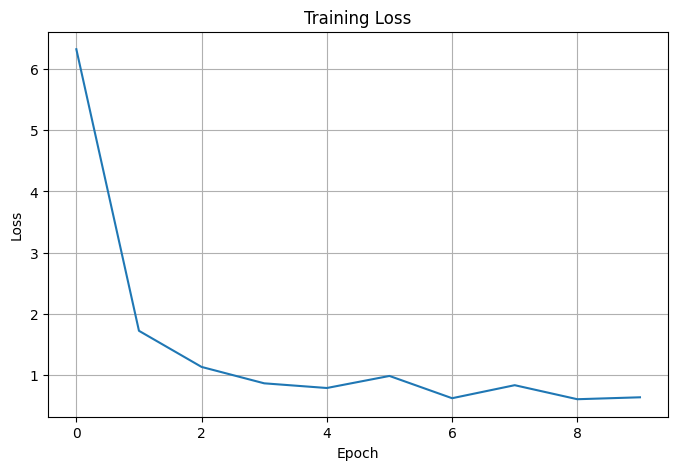

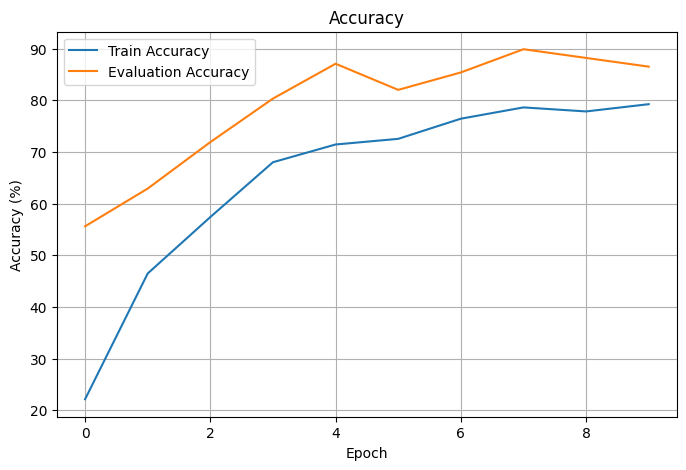

In [27]:
# Plot training results

plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(eval_accuracies, label="Evaluation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


              precision    recall  f1-score   support

           0       1.00      0.50      0.67         4
           1       0.67      0.92      0.77        13
          10       0.67      1.00      0.80         8
          11       1.00      0.79      0.88        14
          12       1.00      1.00      1.00         9
          13       0.82      0.97      0.89        33
           2       1.00      0.64      0.78        11
           3       1.00      0.80      0.89        10
           4       1.00      1.00      1.00        10
           5       1.00      1.00      1.00        12
           6       1.00      1.00      1.00        17
           7       0.86      0.86      0.86         7
           8       1.00      0.93      0.96        14
           9       1.00      0.81      0.90        16

    accuracy                           0.90       178
   macro avg       0.93      0.87      0.89       178
weighted avg       0.92      0.90      0.90       178



<Figure size 1000x800 with 0 Axes>

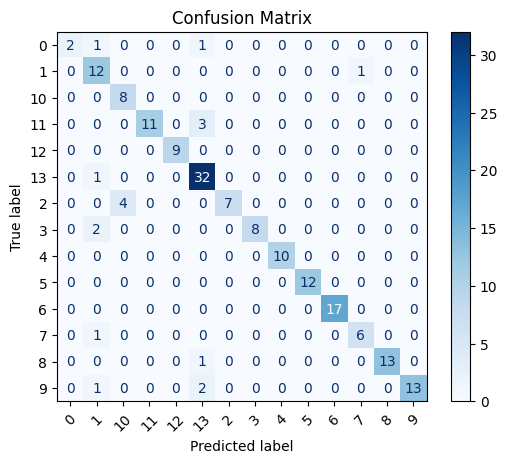

In [28]:


from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

checkpoint = torch.load(MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in eval_loader:
        outputs = model(images.to(DEVICE))
        predictions = outputs.argmax(dim=1).cpu().numpy()

        y_pred.extend(predictions)
        y_true.extend(labels.numpy())

print(classification_report(
    y_true,
    y_pred,
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)
disp.plot(xticks_rotation=45, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


Saving Screenshot 2026-10-07 130949.png to Screenshot 2026-10-07 130949 (1).png


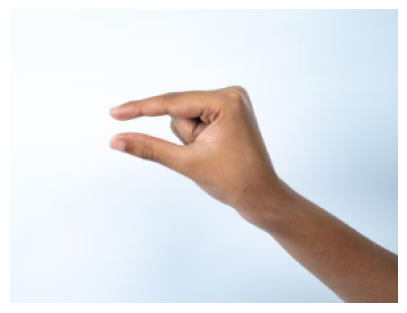

Predicted class: 4
Confidence: 96.92%


In [29]:


from google.colab import files

uploaded_image = files.upload()
image_path = next(iter(uploaded_image))

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")
plt.show()

input_tensor = test_transform(image).unsqueeze(0).to(DEVICE)

model.eval()

with torch.no_grad():
    output = model(input_tensor)
    probabilities = torch.softmax(output, dim=1)
    confidence, predicted = probabilities.max(dim=1)

predicted_class = class_names[predicted.item()]

print("Predicted class:", predicted_class)
print("Confidence:", f"{confidence.item() * 100:.2f}%")


In [30]:


from google.colab import files
files.download(MODEL_PATH)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>